# CNN for cat & dog classification Chapter 9 Workshop 2

## Load module

In [246]:
import numpy as np
import matplotlib.pyplot as plt
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, AvgPool2D

## Define Path and Input shape

In [216]:
train_dir = './datasets/train_set'
test_dir = './datasets/test_set'
val_dir = './datasets/val_set'

target_img_shape = (64,64)

## Load train data

### Define Nomaliztion

In [217]:
train_datagen = ImageDataGenerator(rescale=1./255)

### Load data

In [218]:
train_set = train_datagen.flow_from_directory(train_dir,
                                             target_size=target_img_shape,
                                             batch_size=32,
                                             class_mode='binary')

Found 15997 images belonging to 2 classes.


## Load validation data

### Define Nomaliztion

In [219]:
val_datagen = ImageDataGenerator(rescale=1./255)

### Load data

In [220]:
val_set = val_datagen.flow_from_directory(val_dir,
                                             target_size=target_img_shape,
                                             batch_size=32,
                                             class_mode='binary')

Found 2000 images belonging to 2 classes.


## Visualization

### Check number in train data

In [221]:
print('Traning')

train_ids, train_counts = np.unique(train_set.classes, return_counts=True)

print(train_ids)
print(train_counts)

Traning
[0 1]
[7997 8000]


In [222]:
labels = (train_set.class_indices)
print(labels)
labels = dict((v, k) for k, v in labels.items())
print(labels)

for i in train_ids:
    print(f"{labels[i]}: {train_counts[i]}")

{'cat': 0, 'dog': 1}
{0: 'cat', 1: 'dog'}
cat: 7997
dog: 8000


### Check number in validation

In [223]:
print('Validation')
val_ids, val_counts = np.unique(val_set.classes, return_counts=True)

Validation


### Ratio validation with train 

In [224]:
print('Ratio Validation/Training set:',(val_counts/train_counts*100).round(2))

Ratio Validation/Training set: [12.5 12.5]


### show detail in data_set

In [225]:
print('(W, H, Ch): ',(train_set[0][0][0]).shape)
print('len layer 0 : ',len(train_set))          # 313   # Number of Batch size 
print('len layer 1 : ',len(train_set[1]))       # 2     # data and label
print('len layer 2 : ',len(train_set[32][1]))   # 32    # Batch size number

(W, H, Ch):  (64, 64, 3)
len layer 0 :  500
len layer 1 :  2
len layer 2 :  32


image_batch.shape:  (32, 64, 64, 3)
labels_batch.shape:  (32,)
labels_batch[0]:  1.0


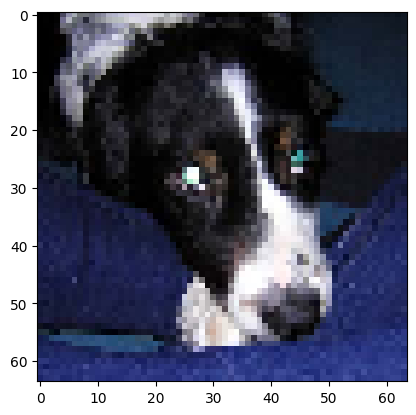

In [226]:
for image_batch, labels_batch in train_set:
    print('image_batch.shape: ', image_batch.shape)  # (32, 64, 64, 3)
    print('labels_batch.shape: ', labels_batch.shape) # (32,)
    plt.imshow(image_batch[0])
    print('labels_batch[0]: ', labels_batch[0]) # 1.0
    break

### train image sample

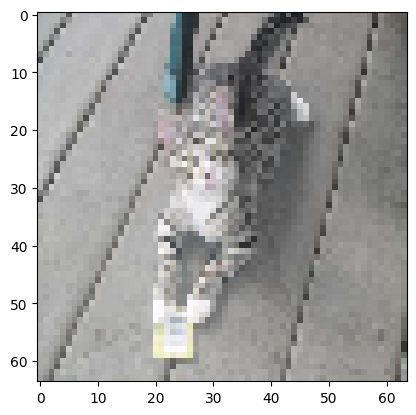

In [227]:
plt.imshow(train_set[2][0][2])
plt.show()

### validation image sample

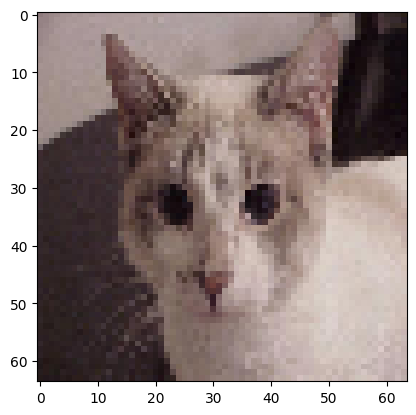

In [228]:
plt.imshow(val_set[2][0][2])
plt.show()

## Create model VGG16

### Define input shape

In [229]:
img = train_set[0][0][0]
in_shape = (img.shape[0], img.shape[1], 3)
print('in_shape: ', in_shape) # (64, 64, 3)

in_shape:  (64, 64, 3)


### Create model

In [230]:
# model = Sequential()

# model.add(Conv2D(64, (3, 3), activation='relu', input_shape=in_shape))
# model.add(Conv2D(64, (3, 3), activation='relu'))
# model.add(MaxPooling2D(pool_size=(2, 2)))

# model.add(Conv2D(128, (3, 3), activation='relu'))
# model.add(Conv2D(128, (3, 3), activation='relu'))
# model.add(MaxPooling2D(pool_size=(2, 2)))

# model.add(Conv2D(256, (3, 3), activation='relu'))
# model.add(Conv2D(256, (3, 3), activation='relu'))
# model.add(Conv2D(256, (3, 3), activation='relu'))
# model.add(MaxPooling2D(pool_size=(2, 2)))

# model.add(Conv2D(512, (3, 3), activation='relu'))
# model.add(Conv2D(512, (3, 3), activation='relu'))
# model.add(Conv2D(512, (3, 3), activation='relu'))
# model.add(MaxPooling2D(pool_size=(2, 2)))

# model.add(Conv2D(512, (3, 3), activation='relu'))
# model.add(Conv2D(512, (3, 3), activation='relu'))
# model.add(Conv2D(512, (3, 3), activation='relu'))
# model.add(MaxPooling2D(pool_size=(2, 2)))

# model.add(Flatten())
# model.add(Dense(4096, activation='relu'))
# model.add(Dense(4096, activation='relu'))
# model.add(Dense(4096, activation='relu'))

# model.add(Dense(1, activation='sigmoid'))

# model.summary()

In [231]:
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=in_shape))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_90 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_91 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_92 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## Compile model

In [232]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

## Traning model

In [233]:
import time
start = time.time()

history = model.fit(train_set,
                    steps_per_epoch=len(train_set),
                    epochs=20,
                    validation_data=val_set,
                    verbose=1)

end = time.time()
print('Time taken to train the model: ', (end-start)/60, 'minutes')

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 127s 253ms/step - accuracy: 0.5566 - loss: 0.6811 - val_accuracy: 0.7145 - val_loss: 0.5521
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.7226 - loss: 0.5422 - val_accuracy: 0.7675 - val_loss: 0.4719
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.7792 - loss: 0.4639 - val_accuracy: 0.8125 - val_loss: 0.4067
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.8155 - loss: 0.3995 - val_accuracy: 0.8180 - val_loss: 0.4013
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.8468 - loss: 0.3495 - val_accuracy: 0.8290 - val_loss: 0.3775
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.8586 - loss: 0.3163 - val_accuracy: 0.8105 - val_loss: 0.4249
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.8901 - loss: 0.2589 - val_accuracy: 0.8435 - val_loss: 0.3589
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.9189 - loss: 0.1954 

## Loss and Accuracy Curve

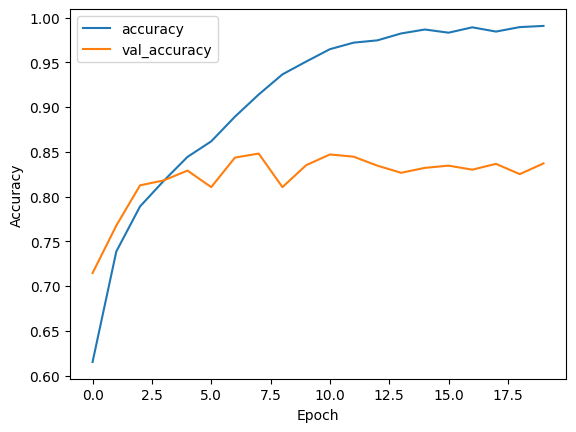

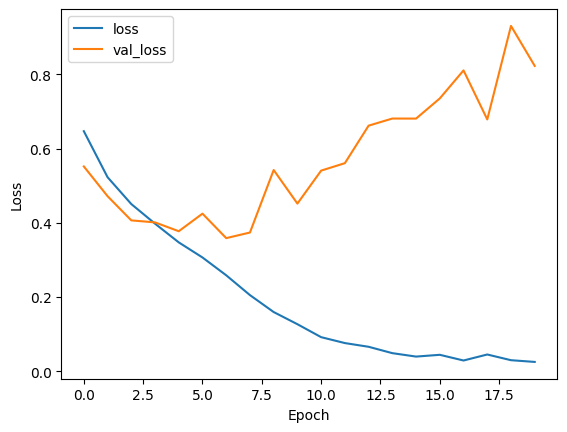

In [234]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Evaluate model

In [237]:
score = model.evaluate(val_set, verbose=0)
# print('Test loss:', score[0])
print('Test accuracy:', round(score[1],3))

Test accuracy: 0.837


## Test model prediction

### load image

In [281]:
test_path = './datasets/test_set/dog9080.jpg'
test_img = load_img(test_path, target_size=target_img_shape)


### Prepare image 

test_img_arr.shape:  (1, 64, 64, 3)


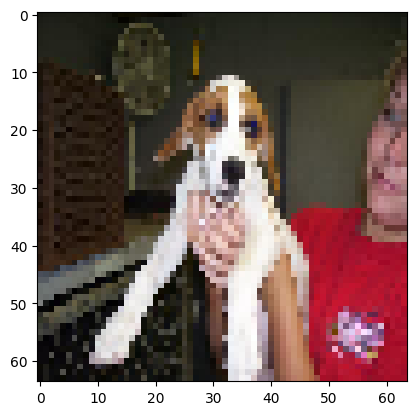

In [282]:
test_img = img_to_array(test_img)
test_img_arr = test_img.astype(np.float32) / 255.0

test_img_arr = np.expand_dims(test_img_arr, axis=0)

print('test_img_arr.shape: ', test_img_arr.shape) # (1, 64, 64, 3)

plt.imshow(test_img_arr[0])
plt.show()

### Prediction

In [283]:
result = model.predict(test_img_arr)
# print('result: ', result[0][0]) # [[0.]]

if result[0][0] > 0.5:
    prediction = 'dog'
else:
    prediction = 'cat'
print('Prediction: ', prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Prediction:  dog


In [284]:
model.save('./model/cat_dog_classification_model.h5')

### Prediction

In [ ]:
pred = model.predict(np.expand_dims(test_img_arr, axis=0))
pred_class = "dog" if pred[0][0] > 0.5 else "cat"
print('pred: ', pred_class)
print('pred[0][0]: ', pred[0][0])
# print('pred[0][1]: ', pred[0][1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
pred:  cat
pred[0][0]:  0.006073111


In [ ]:
train_set.class_indices

{'cat': 0, 'dog': 1}

## Test model multi prediction

### Create function for multi prediction 

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

def predict_dog_cat(model, path_lst):
    imgs = []; cls = []; preds = []
    for path in path_lst:
        test_img = load_img(path, target_size=target_img_shape)
        test_img = img_to_array(test_img)
        test_img_arr = test_img.astype(np.float32) / 255.0
        pred = model.predict(np.expand_dims(test_img_arr, axis=0))
        pred_class = "dog" if pred[0][0] > 0.5 else "cat"

        imgs.append(test_img_arr)
        cls.append(pred_class)
        preds.append(pred)
    return imgs, cls, preds


In [ ]:
import glob
import os

# Get all image paths in the test set directory
path_lst = glob.glob(r'./datasets/test_set/*')

img_arrs, y_pred_cls, y_preds = predict_dog_cat(model, path_lst)

for i in path_lst:
    print(os.path.basename(i), end=' |')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━

d:\Programming_File\Environment\tf\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━

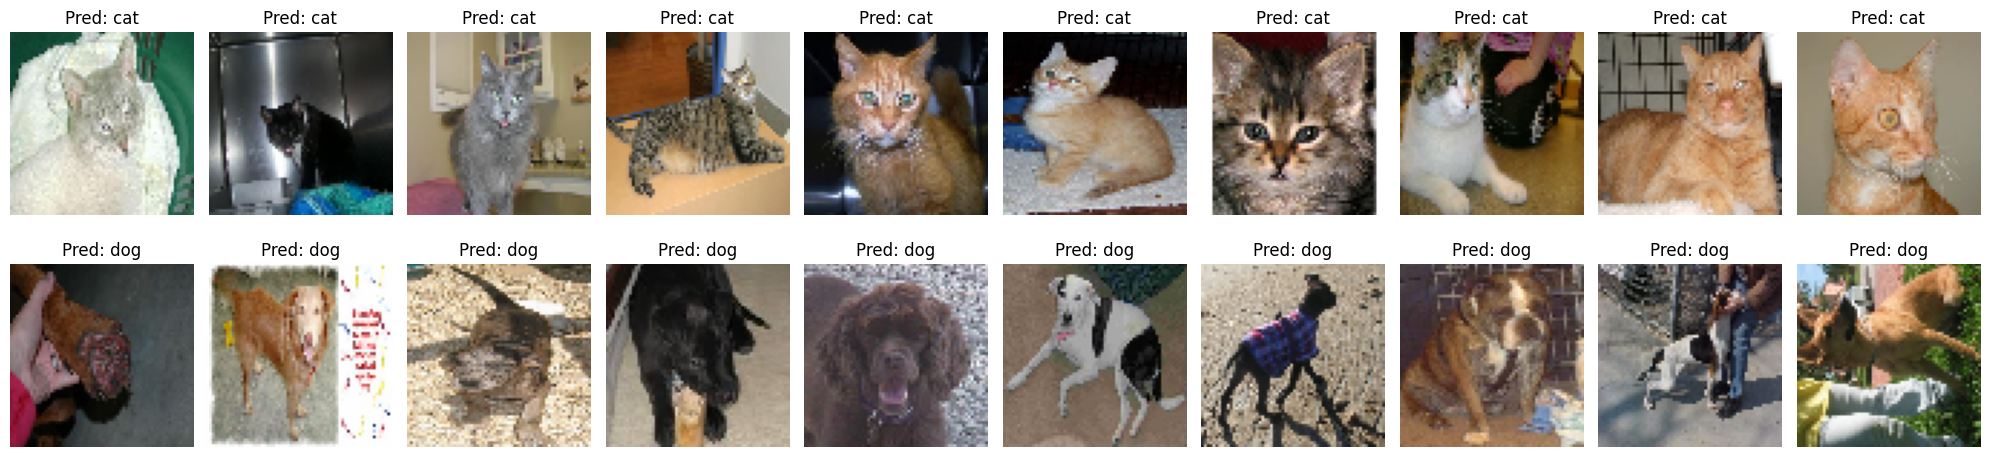

In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
for i in range(20):
    ax1 = axes[0, i%10]
    ax1.imshow(img_arrs[i])
    ax1.set_title(f"Pred: {y_pred_cls[i]}")
    ax1.axis('off')

    ax2 = axes[1, i%10]
    ax2.imshow(img_arrs[-i])
    ax2.set_title(f"Pred: {y_pred_cls[-i]}")
    ax2.axis('off')
plt.tight_layout()
plt.show()